# WakeGuard - Mô Phỏng Hệ Thống Cảnh Báo Buồn Ngủ (Drowsiness Warning System)

Notebook này mô phỏng toàn bộ quy trình xử lý dữ liệu, phân tích đặc trưng EAR (Eye Aspect Ratio) và huấn luyện mô hình học máy SVM dùng để phát hiện trạng thái ngủ gật của tài xế.

--- 
## 1. Khai báo các thư viện cần thiết

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import make_pipeline

# Cấu hình biểu đồ
sns.set_theme(style="whitegrid")
%matplotlib inline
print("Đã import toàn bộ thư viện cần thiết.")

Đã import toàn bộ thư viện cần thiết.


--- 
## 2. Tải và Khám phá Tập dữ liệu (EDA)

Chúng ta sẽ đọc tập dữ liệu từ tệp `data/dataset.csv`. Tệp này lưu trữ các đặc trưng EAR của mắt trái, mắt phải và mắt trung bình được trích xuất từ tập ảnh **MRL Eye Dataset**.

In [2]:
dataset_path = os.path.join("data", "dataset.csv")

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Không tìm thấy tệp dataset tại {dataset_path}. Vui lòng kiểm tra lại đường dẫn!")

df = pd.read_csv(dataset_path)
print(f"Tổng số mẫu dữ liệu: {df.shape[0]}")
print(f"Số cột đặc trưng: {df.shape[1]}")
df.head(10)

Tổng số mẫu dữ liệu: 4564
Số cột đặc trưng: 6


,left_ear,right_ear,avg_ear,label,source,image_path
0,0.117160,0.135574,0.126367,1,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Closed_Eyes\s0001_01684_0_1...
1,0.101108,0.112681,0.106894,1,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Closed_Eyes\s0006_00337_0_1...
2,0.295867,0.416224,0.356045,0,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Open_Eyes\s0001_02876_0_1_1...
3,0.292971,0.333968,0.313470,0,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Open_Eyes\s0012_07839_0_0_1...
4,0.388009,0.335662,0.361836,0,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Open_Eyes\s0035_00160_0_1_1...
5,0.170438,0.179966,0.175202,1,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Closed_Eyes\s0014_00091_0_0...
6,0.175217,0.140490,0.157854,1,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Closed_Eyes\s0016_01319_1_0...
7,0.090611,0.177955,0.134283,1,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Closed_Eyes\s0016_00200_1_0...
8,0.084442,0.094453,0.089448,1,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Closed_Eyes\s0016_01282_1_0...
9,0.313779,0.363814,0.338796,0,Kaggle Drowsiness Detection Dataset / MRL Eye ...,data\raw\mrl\train\Open_Eyes\s0001_03045_0_1_1...


### Kiểm tra sự cân bằng của các nhãn (0 = Mở mắt, 1 = Nhắm mắt)

Phân bố nhãn:
  - Mở mắt (Nhãn 0): 2293 mẫu
  - Nhắm mắt (Nhãn 1): 2271 mẫu


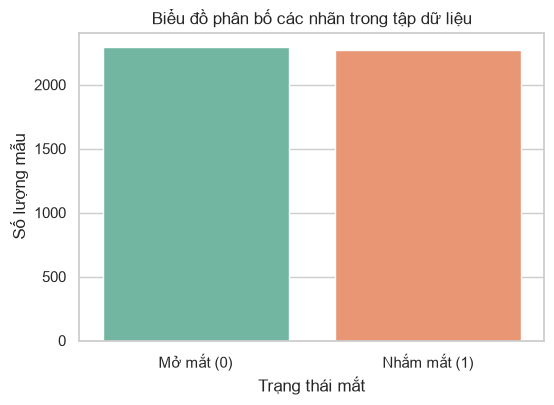

In [3]:
label_counts = df["label"].value_counts()
print("Phân bố nhãn:")
print(f"  - Mở mắt (Nhãn 0): {label_counts.get(0, 0)} mẫu")
print(f"  - Nhắm mắt (Nhãn 1): {label_counts.get(1, 0)} mẫu")

plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df, hue="label", legend=False, palette="Set2")
plt.xticks([0, 1], ["Mở mắt (0)", "Nhắm mắt (1)"])
plt.title("Biểu đồ phân bố các nhãn trong tập dữ liệu")
plt.xlabel("Trạng thái mắt")
plt.ylabel("Số lượng mẫu")
plt.show()

### Trực quan hóa Phân bố của EAR (Eye Aspect Ratio)

EAR là thương số tính từ khoảng cách giữa các điểm mốc mí mắt. Trạng thái mắt mở sẽ có EAR cao (thường từ 0.25 - 0.45), nhắm mắt sẽ có EAR thấp (dưới 0.20).

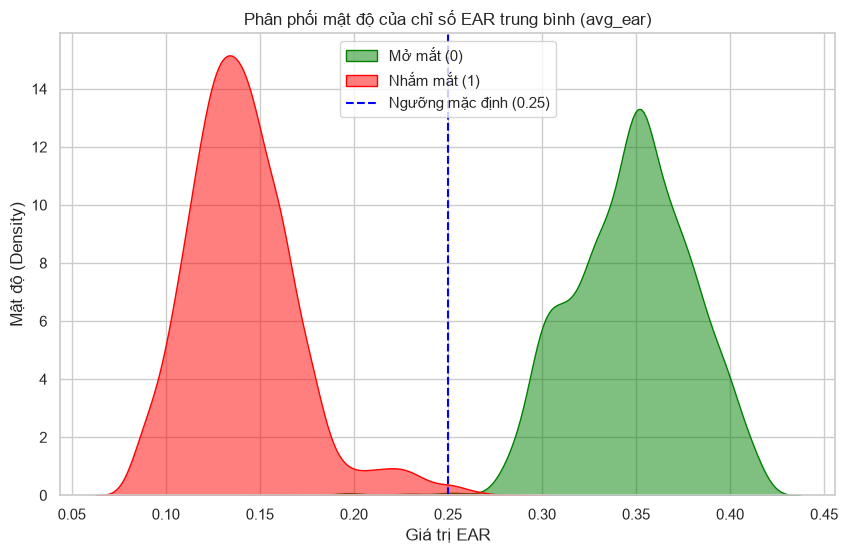

In [4]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df["label"] == 0], x="avg_ear", fill=True, label="Mở mắt (0)", color="green", alpha=0.5)
sns.kdeplot(data=df[df["label"] == 1], x="avg_ear", fill=True, label="Nhắm mắt (1)", color="red", alpha=0.5)
plt.axvline(x=0.25, color='blue', linestyle='--', label='Ngưỡng mặc định (0.25)')
plt.title("Phân phối mật độ của chỉ số EAR trung bình (avg_ear)")
plt.xlabel("Giá trị EAR")
plt.ylabel("Mật độ (Density)")
plt.legend()
plt.show()

Qua biểu đồ trên, ta thấy sự phân tách rõ ràng giữa EAR khi mở mắt và nhắm mắt. 
- Ngưỡng heuristic cố định (0.25) hoạt động tương đối ổn cho đa số trường hợp.
- Tuy nhiên, đối với người đeo kính hoặc cấu trúc mắt đặc biệt, các phân phối này có thể dịch chuyển, đó là lý do mô hình học máy (SVM) sẽ giúp tìm ra ranh giới tối ưu hơn.

--- 
## 3. Huấn luyện Mô hình Học Máy SVM

Chúng ta tách tập dữ liệu thành các đặc trưng đầu vào `X` và nhãn đích `y`, phân chia tập Train/Test theo tỉ lệ 80/20, sau đó huấn luyện mô hình SVM sử dụng RBF Kernel.

In [5]:
# Lọc các đặc trưng
features = ["left_ear", "right_ear", "avg_ear"]
X = df[features]
y = df["label"]

# Chia Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Kích thước tập Train: {X_train.shape[0]} mẫu")
print(f"Kích thước tập Test: {X_test.shape[0]} mẫu")

Kích thước tập Train: 3651 mẫu
Kích thước tập Test: 913 mẫu


### Xây dựng Pipeline chuẩn hóa và Huấn luyện

In [6]:
# Tạo Pipeline: Chuẩn hóa đặc trưng (StandardScaler) -> Phân loại SVM (SVC)
pipeline = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale"))
pipeline.fit(X_train, y_train)
print("Đã huấn luyện xong mô hình SVM.")

Đã huấn luyện xong mô hình SVM.


--- 
## 4. Đánh giá Mô hình

In [7]:
# Dự đoán trên tập kiểm thử
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác toàn cục (Accuracy): {accuracy * 100:.2f}%")
print("\nBáo cáo phân loại (Classification Report):")
print(classification_report(y_test, y_pred, target_names=["Mở mắt (Open)", "Nhắm mắt (Closed)"]))

Độ chính xác toàn cục (Accuracy): 99.34%

Báo cáo phân loại (Classification Report):
                   precision    recall  f1-score   support

    Mở mắt (Open)       1.00      0.99      0.99       459
Nhắm mắt (Closed)       0.99      1.00      0.99       454

         accuracy                           0.99       913
        macro avg       0.99      0.99      0.99       913
     weighted avg       0.99      0.99      0.99       913



### Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix)

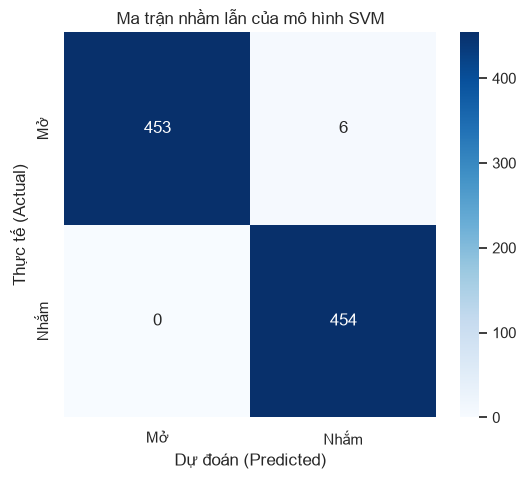

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Mở", "Nhắm"], yticklabels=["Mở", "Nhắm"])
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.title('Ma trận nhầm lẫn của mô hình SVM')
plt.show()

--- 
## 5. Mô Phỏng Quá Trình Nhận Diện Thời Gian Thực

Dưới đây là hàm giả lập bộ phân loại trạng thái mắt. Khi camera ghi nhận các đặc trưng mắt của bạn, hệ thống sẽ đưa qua hàm này để dự đoán và ra quyết định cảnh báo nếu nhắm mắt liên tục vượt quá số khung hình quy định.

In [9]:
def simulate_eye_state_detector(left, right):
    """
    Mô phỏng chức năng nhận diện trạng thái mắt dựa trên mô hình SVM đã huấn luyện.
    """
    avg = (left + right) / 2.0
    # Tạo DataFrame để khớp với tên đặc trưng
    input_data = pd.DataFrame([[left, right, avg]], columns=["left_ear", "right_ear", "avg_ear"])
    
    # Dự đoán
    pred = pipeline.predict(input_data)[0]
    
    state = "NHẮM MẮT (Closed)" if pred == 1 else "MỞ MẮT (Open)"
    print(f"Chỉ số nhận diện: Left={left:.3f}, Right={right:.3f}, Average={avg:.3f}")
    print(f"=> Trạng thái dự đoán của mô hình: {state}\n")
    return pred

# Kiểm thử các trường hợp khác nhau:
print("--- Thử nghiệm 1: Mắt mở to bình thường ---")
simulate_eye_state_detector(0.38, 0.36)

print("--- Thử nghiệm 2: Mắt nhắm chặt ---")
simulate_eye_state_detector(0.12, 0.11)

print("--- Thử nghiệm 3: Trạng thái lờ đờ / mỏi mắt / đeo kính bị lệch chỉ số ---")
simulate_eye_state_detector(0.22, 0.23)

--- Thử nghiệm 1: Mắt mở to bình thường ---
Chỉ số nhận diện: Left=0.380, Right=0.360, Average=0.370
=> Trạng thái dự đoán của mô hình: MỞ MẮT (Open)

--- Thử nghiệm 2: Mắt nhắm chặt ---
Chỉ số nhận diện: Left=0.120, Right=0.110, Average=0.115
=> Trạng thái dự đoán của mô hình: NHẮM MẮT (Closed)

--- Thử nghiệm 3: Trạng thái lờ đờ / mỏi mắt / đeo kính bị lệch chỉ số ---
Chỉ số nhận diện: Left=0.220, Right=0.230, Average=0.225
=> Trạng thái dự đoán của mô hình: NHẮM MẮT (Closed)



np.int64(1)

--- 
## 6. Mô Phỏng Bộ Đếm Khung Hình Cảnh Báo (Drowsiness Alert Logic)

Hệ thống sẽ không cảnh báo ngay lập tức khi bạn chớp mắt (nhắm mắt 1-2 khung hình). Cảnh báo chỉ kích hoạt khi bạn nhắm mắt liên tục vượt quá `CONSECUTIVE_FRAMES` (mặc định là 15 khung hình, tương đương khoảng 0.5 giây).

In [10]:
# Giả lập chuỗi trạng thái mắt đọc được từ camera qua thời gian
# 0 = Mở, 1 = Nhắm
simulated_stream = [0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]

consec_max = 15
counter = 0
alarm_active = False

print(f"Bắt đầu mô phỏng luồng stream với ngưỡng khung hình nhắm mắt liên tục = {consec_max}\n")
for frame_idx, state in enumerate(simulated_stream):
    if state == 1:
        counter += 1
        status = f"[Nhắm mắt] Bộ đếm: {counter}/{consec_max}"
        if counter >= consec_max:
            if not alarm_active:
                alarm_active = True
                status += " -> !!! KÍCH HOẠT CÒI BÁO ĐỘNG (ALARM ON) !!!"
            else:
                status += " -> [Còi vẫn kêu]"
    else:
        counter = 0
        status = "[Mở mắt] Bộ đếm reset về 0"
        if alarm_active:
            alarm_active = False
            status += " -> Tắt còi báo động (ALARM OFF)"
            
    print(f"Khung hình #{frame_idx + 1:02d}: {status}")

Bắt đầu mô phỏng luồng stream với ngưỡng khung hình nhắm mắt liên tục = 15

Khung hình #01: [Mở mắt] Bộ đếm reset về 0
Khung hình #02: [Mở mắt] Bộ đếm reset về 0
Khung hình #03: [Mở mắt] Bộ đếm reset về 0
Khung hình #04: [Nhắm mắt] Bộ đếm: 1/15
Khung hình #05: [Mở mắt] Bộ đếm reset về 0
Khung hình #06: [Mở mắt] Bộ đếm reset về 0
Khung hình #07: [Nhắm mắt] Bộ đếm: 1/15
Khung hình #08: [Nhắm mắt] Bộ đếm: 2/15
Khung hình #09: [Nhắm mắt] Bộ đếm: 3/15
Khung hình #10: [Nhắm mắt] Bộ đếm: 4/15
Khung hình #11: [Nhắm mắt] Bộ đếm: 5/15
Khung hình #12: [Nhắm mắt] Bộ đếm: 6/15
Khung hình #13: [Nhắm mắt] Bộ đếm: 7/15
Khung hình #14: [Nhắm mắt] Bộ đếm: 8/15
Khung hình #15: [Nhắm mắt] Bộ đếm: 9/15
Khung hình #16: [Nhắm mắt] Bộ đếm: 10/15
Khung hình #17: [Nhắm mắt] Bộ đếm: 11/15
Khung hình #18: [Nhắm mắt] Bộ đếm: 12/15
Khung hình #19: [Nhắm mắt] Bộ đếm: 13/15
Khung hình #20: [Nhắm mắt] Bộ đếm: 14/15
Khung hình #21: [Nhắm mắt] Bộ đếm: 15/15 -> !!! KÍCH HOẠT CÒI BÁO ĐỘNG (ALARM ON) !!!
Khung hình #22: [N